In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import f1_score

In [3]:
iris = load_iris() 
features = iris.data

data = pd.DataFrame(features, columns = iris.feature_names)
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [13]:
X = data.iloc[:, [0, 2]]
y = iris.target
X.shape, y.shape

((150, 2), (150,))

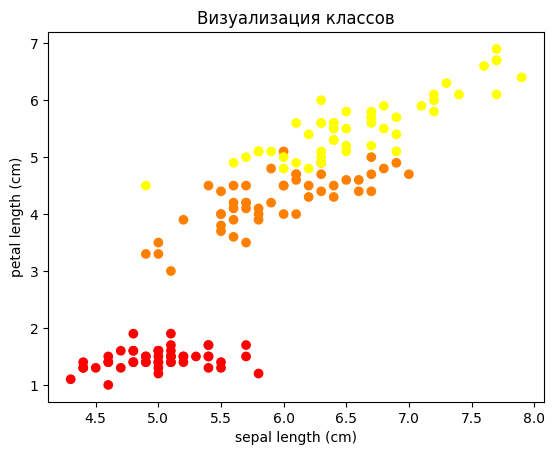

In [5]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn')

plt.title("Визуализация классов")
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.show()

In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

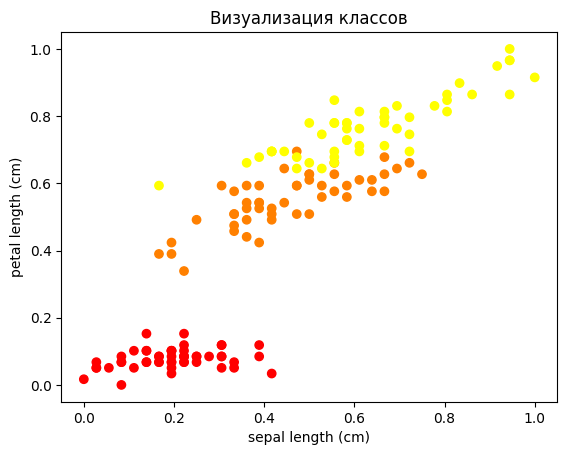

In [9]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn')

plt.title("Визуализация классов")
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.show()

In [15]:
from sklearn.neighbors import KNeighborsClassifier 

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

y_pred = knn.predict(X_scaled)

In [14]:
import seaborn as sns

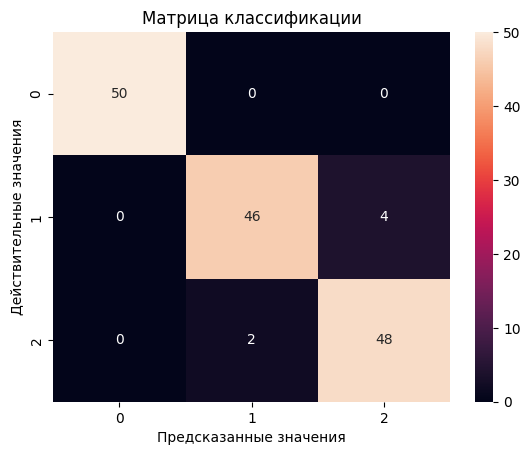

In [15]:
plt.title("Матрица классификации")
sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt ='d')
plt.ylabel('Действительные значения')
plt.xlabel('Предсказанные значения')
plt.show()

In [17]:
from sklearn.metrics import classification_report

In [18]:
print(classification_report(y_pred, y))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.92      0.96      0.94        48
           2       0.96      0.92      0.94        52

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



In [16]:
X0 = np.linspace(X.iloc[:, 0].min()-1,X.iloc[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X.iloc[:, 1].min()-1,X.iloc[:, 1].max()+1, X.shape[0])

X0_grid, X1_grid = np.meshgrid(X0, X1)

XX = np.array([X0_grid.ravel(), X1_grid.ravel()]).T

In [17]:
XX_scaled = scaler.transform(XX)
Z = knn.predict(XX_scaled).reshape(X0_grid.shape)

/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


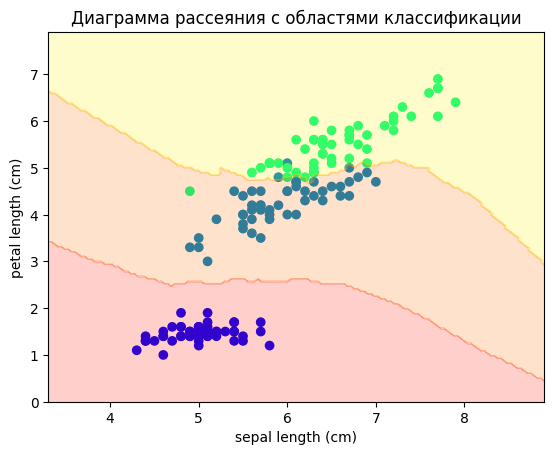

In [21]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='winter')
plt.contourf(X0_grid, X1_grid, Z, cmap='autumn', alpha=0.2)

plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.title("Диаграмма рассеяния с областями классификации")
plt.show()

In [23]:
observation_new = [[5.5, 5]]

In [24]:
observation_new_scaled = scaler.transform(observation_new)

/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [27]:
knn.predict(observation_new_scaled)

array([2])

In [28]:
knn.predict_proba(observation_new_scaled)

array([[0., 0., 1.]])

In [25]:
distances, indices = knn.kneighbors(observation_new_scaled)

In [33]:
X0_min, X0_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
X1_min, X1_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5

X0 = np.linspace(X0_min, X0_max, 200)
X1 = np.linspace(X1_min, X1_max, 200)
X0_grid, X1_grid = np.meshgrid(X0, X1)

XX_scaled = np.array([X0_grid.ravel(), X1_grid.ravel()]).T

Z = knn.predict(XX_scaled).reshape(X0_grid.shape)

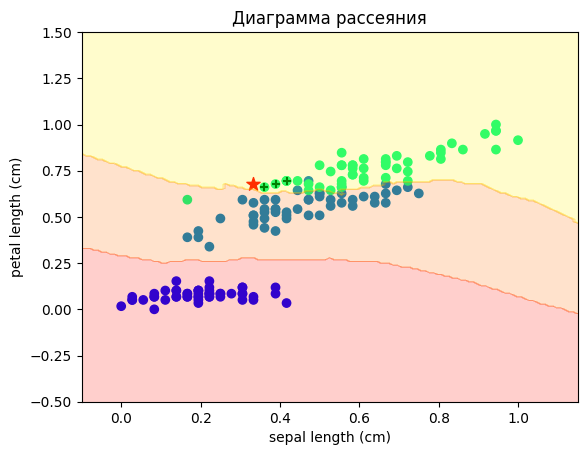

In [38]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='winter')

plt.scatter(observation_new_scaled[0][0], observation_new_scaled[0][1], marker='*', color='r', s=100)

plt.contourf(X0_grid, X1_grid, Z, cmap='autumn', alpha=0.2)

plt.scatter(X_scaled[indices[0]][0][0], X_scaled[indices[0]][0][1], marker='+', color='g')
plt.scatter(X_scaled[indices[0]][1][0], X_scaled[indices[0]][1][1], marker='+', color='g')
plt.scatter(X_scaled[indices[0]][2][0], X_scaled[indices[0]][2][1], marker='+', color='g')

plt.title("Диаграмма рассеяния")
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.xlim([-0.1, 1.15])
plt.show()

## Практическая работа

### 1. Исходное пространство, последний график

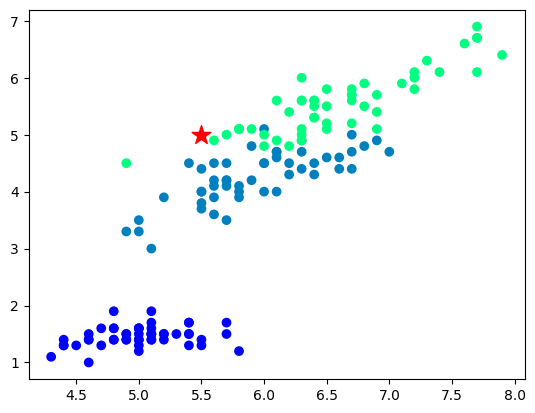

In [40]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='winter')
plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', color='r', s=200)

### 2. Другие значения k

In [53]:
x_min, x_max = X.iloc[:, 0].min() - 0.5, X.iloc[:, 0].max() + 0.5
y_min, y_max = X.iloc[:, 1].min() - 0.5, X.iloc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

In [54]:
k_values = [1, 3, 5, 10, 20]

/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:

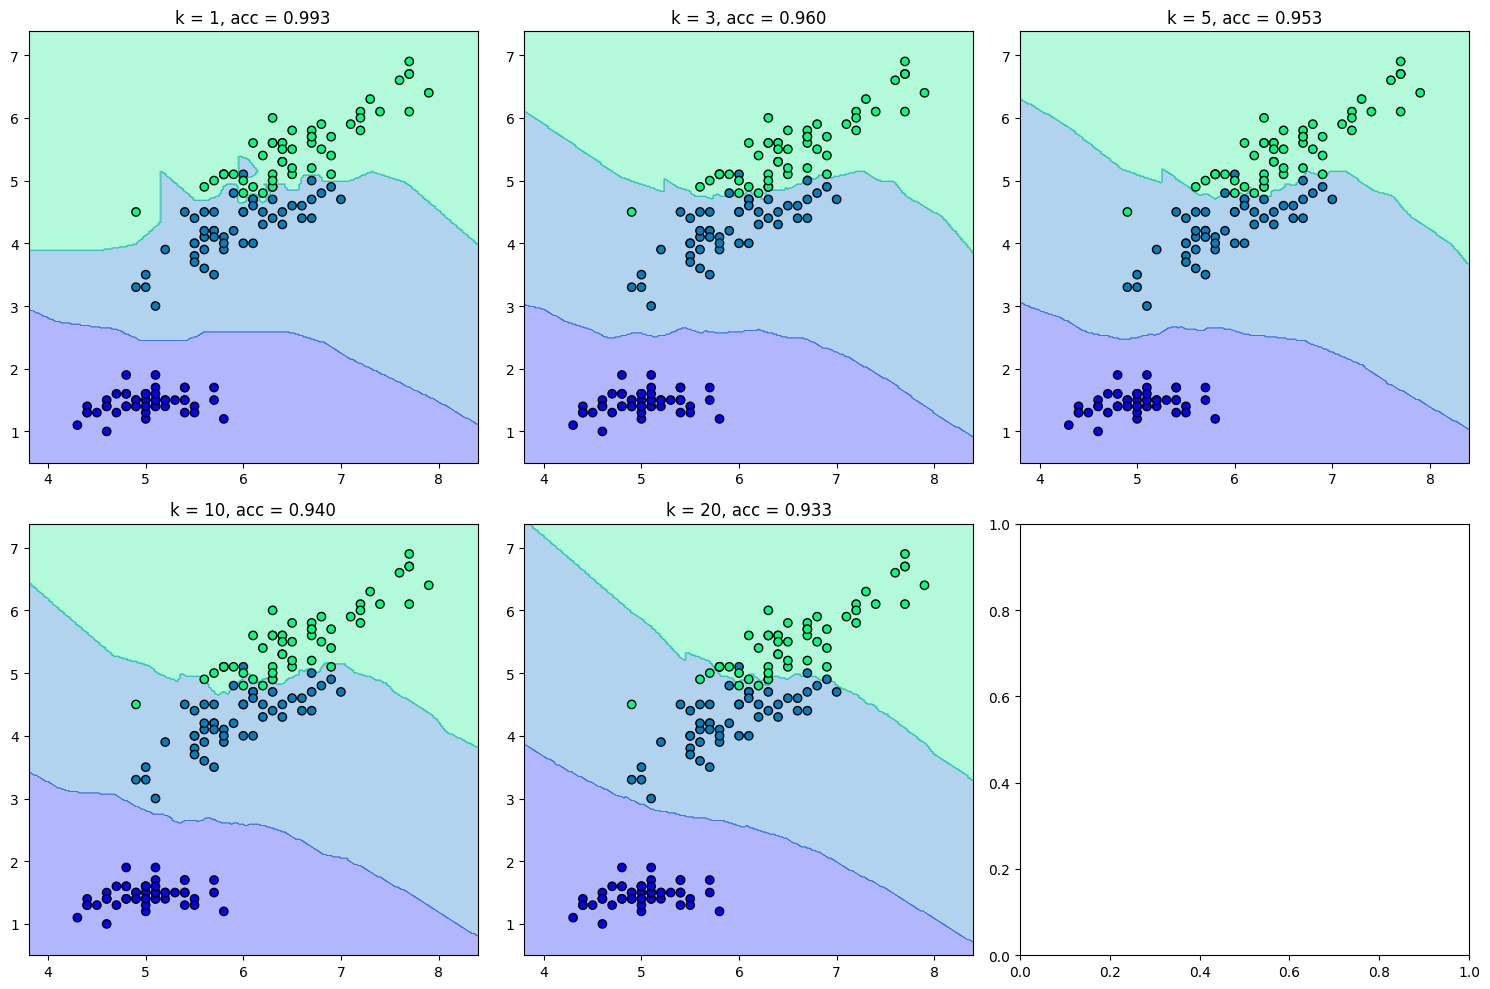

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, k in enumerate(k_values):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_scaled, y_arr)
    
    Z = knn.predict(scaler.transform(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap='winter')
    axes[idx].scatter(X_arr[:, 0], X_arr[:, 1], c=y_arr, cmap='winter', edgecolors='black')
    axes[idx].set_title(f'k = {k}, acc = {accuracy_score(y_arr, knn.predict(X_scaled)):.3f}')

plt.tight_layout()
plt.show()

### 3. Новое наблюдение двигаем за пределы области

In [58]:
observations = [[5.5, 5], [7.5, 7], [4, 1], [6, 3], [8, 8]]

In [59]:
for obs in observations:
    obs_scaled = scaler.transform([obs])
    print(f"{obs} -> {obs_scaled[0]}")

[5.5, 5] -> [0.33333333 0.6779661 ]
[7.5, 7] -> [0.88888889 1.01694915]
[4, 1] -> [-0.08333333  0.        ]
[6, 3] -> [0.47222222 0.33898305]
[8, 8] -> [1.02777778 1.18644068]


/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:

**Вывод:**
- Значения **внутри** исходного диапазона → от **0 до 1**
- Значения **ниже** минимума → **отрицательные**
- Значения **выше** максимума → **больше 1**

### 4. Разные метрики расстояния 

In [60]:
observation_new = [[5.5, 5]]
observation_new_scaled = scaler.transform(observation_new)

/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [62]:
metrics = ['euclidean', 'manhattan', 'chebyshev', 'minkowski']

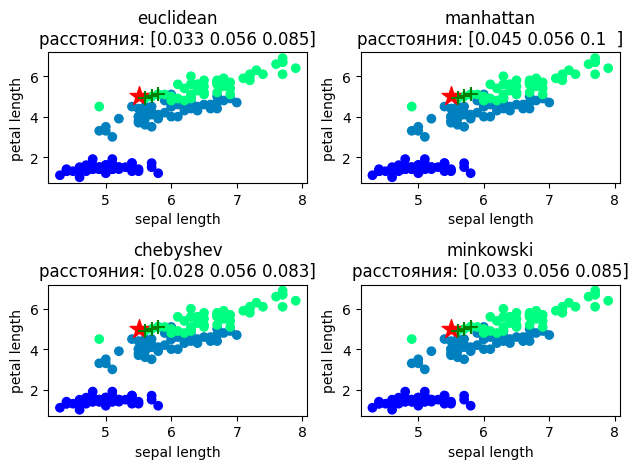

In [69]:
for idx, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, idx)
    
    knn = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn.fit(X_scaled, y)
    
    distances, indices = knn.kneighbors(observation_new_scaled)
    
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='winter')
    plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', color='red', s=200)
    
    for i in range(3):
        idx_neighbor = indices[0][i]
        plt.scatter(X.iloc[idx_neighbor, 0], X.iloc[idx_neighbor, 1], 
                   marker='+', color='green', s=100)
    
    plt.title(f'{metric}\nрасстояния: {distances[0].round(3)}')
    plt.xlabel('sepal length')
    plt.ylabel('petal length')

plt.tight_layout()
plt.show()

Все метрики показали **одинаковый набор ближайших соседей** (второе расстояние 0.0556 совпадает у всех), но с разными значениями:

- **chebyshev** дал наименьшие расстояния (0.0278, 0.0556, 0.0833)
- **euclidean** и **minkowski** дали одинаковые результаты (p=2)
- **manhattan** дал наибольшие расстояния

### 5. Обучение на полном датасете

In [71]:
X_full = iris.data
y_full = iris.target

In [72]:
scaler_full = MinMaxScaler()
X_full_scaled = scaler_full.fit_transform(X_full)

In [73]:
k_values = [1, 3, 5, 10, 20]

In [74]:
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_full_scaled, y_full)
    y_pred = knn.predict(X_full_scaled)
    acc = accuracy_score(y_full, y_pred)
    print(f"k = {k:2d}: Accuracy = {acc:.4f}")

k =  1: Accuracy = 1.0000
k =  3: Accuracy = 0.9667
k =  5: Accuracy = 0.9600
k = 10: Accuracy = 0.9667
k = 20: Accuracy = 0.9733


In [75]:
X_2features = iris.data[:, [0, 2]]
X_2features_scaled = MinMaxScaler().fit_transform(X_2features)

for k in [3]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_2features_scaled, y_full)
    acc = accuracy_score(y_full, knn.predict(X_2features_scaled))
    print(f"2 признака, k={k}: Accuracy = {acc:.4f}")

2 признака, k=3: Accuracy = 0.9600


- **На 4 признаках:** лучший результат **k=1** (100% точность), но риск переобучения
- **На 2 признаках:** **k=3** (96% точности) — как в методичке
- Добавление признаков повышает качество классификации
- Оптимально: **k=3** (хороший баланс между точностью и обобщением)

### 6. Взвешенный алгоритм 

In [76]:
X_full_scaled = MinMaxScaler().fit_transform(iris.data)
y_full = iris.target

In [77]:
k_values = [1, 3, 5, 10, 20]

In [79]:
for k in k_values:
    knn_uniform = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    knn_uniform.fit(X_full_scaled, y_full)
    acc_uniform = accuracy_score(y_full, knn_uniform.predict(X_full_scaled))

    knn_distance = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_distance.fit(X_full_scaled, y_full)
    acc_distance = accuracy_score(y_full, knn_distance.predict(X_full_scaled))
    
    print(f"k={k:2d} | {acc_uniform:.4f} | {acc_distance:.4f}")

k= 1 | 1.0000 | 1.0000
k= 3 | 0.9667 | 1.0000
k= 5 | 0.9600 | 1.0000
k=10 | 0.9667 | 1.0000
k=20 | 0.9733 | 1.0000


- **uniform** (равномерный): точность ~96-100%, падает при k>1
- **distance** (взвешенный): **стабильные 100%** при любом k

Взвешенный алгоритм (weights='distance') значительно эффективнее на полном датасете, так как ближайшие соседи получают больший вес, что повышает качество классификации.

### 7. График точности модели в зависимости от значения k

In [80]:
X_full_scaled = MinMaxScaler().fit_transform(iris.data)
y_full = iris.target

In [81]:
k_range = range(1, 31)
acc_uniform = []
acc_distance = []

In [82]:
for k in k_range:
    knn_uniform = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    knn_uniform.fit(X_full_scaled, y_full)
    acc_uniform.append(accuracy_score(y_full, knn_uniform.predict(X_full_scaled)))
    
    knn_distance = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_distance.fit(X_full_scaled, y_full)
    acc_distance.append(accuracy_score(y_full, knn_distance.predict(X_full_scaled)))

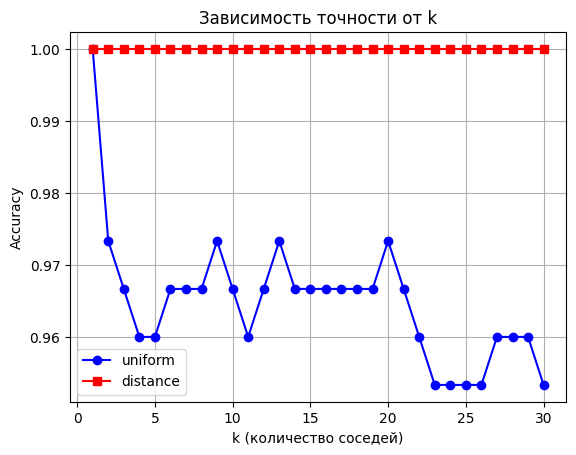

In [88]:
plt.plot(k_range, acc_uniform, 'b-', label='uniform', marker='o')
plt.plot(k_range, acc_distance, 'r-', label='distance', marker='s')
plt.xlabel('k (количество соседей)')
plt.ylabel('Accuracy')
plt.title('Зависимость точности от k')
plt.legend()
plt.grid()
plt.show()

uniform: точность падает при k>1, оптимально k=1 (100%)

### 8. Регрессия с помощью кнн

In [93]:
from sklearn.neighbors import KNeighborsRegressor

In [89]:
housing = fetch_california_housing()
X = housing.data[:, [0, 2]]
y = housing.target

In [90]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [91]:
k_values = [3, 5, 10, 20]

In [96]:
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_scaled, y)
    y_pred = knn.predict(X_scaled)
    
    r2 = knn.score(X_scaled, y)
    print(f"{k:2d} | {r2:.4f}")

 3 | 0.7046
 5 | 0.6436
10 | 0.5998
20 | 0.5753


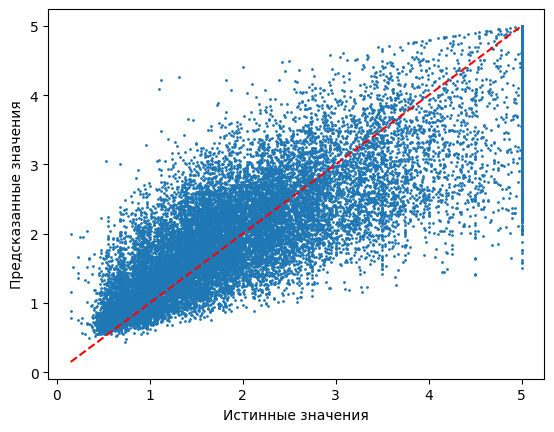

In [101]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_scaled, y)
y_pred = knn.predict(X_scaled)

plt.scatter(y, y_pred, s=1)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.show()

- **Наилучший результат:** k=3 (R² = 0.7046)
- **С ростом k** точность снижается: k=20 (R² = 0.5753)
- KNN регрессия лучше работает с **меньшим k**, так как учитывает только ближайших соседей
- Для регрессии KNN уступает другим методам (деревья решений, линейная регрессия)